## 1. Carga y Gestión de Datos con SQLite (Regresión)

En esta sección se describe el proceso de preparación y gestión del dataset de regresión, desde su estado original (*raw*) hasta su almacenamiento en una base de datos SQLite para su posterior análisis.

---

### 1.1 Datos de entrada (Raw)

El análisis parte del archivo:

- dataset_regresion.csv, ubicado en la carpeta data/raw/

Este dataset contiene información sobre ventas de viviendas en el condado de King (Seattle, EE.UU.), incluyendo variables estructurales, de calidad y de ubicación.

Los datos en esta etapa se encuentran en su forma original, sin transformaciones.

---

### 1.2 Procesamiento intermedio (Interim)

Antes del análisis exploratorio, los datos fueron sometidos a una etapa de limpieza estructural mediante un script ubicado en la carpeta src.

En este proceso se realizaron las siguientes transformaciones:

- Eliminación de la variable id, ya que corresponde a un identificador sin valor analítico.

- Transformación de la variable date, convirtiéndola a formato de fecha y extrayendo nuevas variables:
  - sale_year
  - sale_month

  Esto permite analizar posibles patrones temporales en los precios.

- Conversión de la variable zipcode a tipo categórico (string), evitando interpretaciones numéricas incorrectas.

- Creación de la variable is_renovated, definida como:
  - 1 si la vivienda ha sido renovada
  - 0 en caso contrario

  Esta transformación simplifica la interpretación de la variable yr_renovated.

Es importante destacar que en esta etapa no se alteran las distribuciones de los datos, ya que los valores atípicos se preservan para su análisis en el EDA.

El resultado de este proceso se almacena en:

- data/interim/dataset_regresion_interim.csv

---

### 1.3 Creación de la base de datos SQLite

Para gestionar los datos de forma estructurada, se implementó un script encargado de la creación de la base de datos.

Este script realiza las siguientes operaciones:

1. Crea una base de datos en la carpeta database del proyecto.

2. Importa el dataset en su versión interim.

3. Crea una tabla denominada housing, que contiene los datos del problema de regresión.

4. Inserta los datos utilizando funciones de la librería pandas, permitiendo almacenar el dataset en formato relacional.

---

### 1.4 Consultas SQL

Una vez almacenados los datos en SQLite, se ejecutan consultas SQL con el objetivo de obtener una primera aproximación a la estructura del dataset.

Las consultas realizadas incluyen:

- Conteo total de registros
- Cálculo de valores mínimos, máximos y promedios
- Agrupaciones por variables relevantes (por ejemplo, calidad de construcción)
- Filtros para identificar propiedades de alto valor

Estas consultas permiten comprender el comportamiento general de los datos antes de realizar el análisis exploratorio en Python.

---

En las siguientes celdas se presentan los resultados de estas consultas.
---
### 1.5 Visualización inicial del dataset

Antes de realizar las consultas SQL, se procede a inspeccionar el dataset en su versión *interim* mediante la visualización de las primeras filas y la estructura general de los datos.

Esto permite verificar que las transformaciones previas se aplicaron correctamente y comprender la organización de las variables.

In [ ]:
df = pd.read_csv("../data/interim/dataset_regresion_interim.csv")
df.head()

,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,...,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15,sale_year,sale_month,is_renovated
0,2014-10-13,221900.0,3,1.00,1180,5650,1.0,0,0,3,...,1955,0,98178,47.5112,-122.257,1340,5650,2014,10,0
1,2014-12-09,538000.0,3,2.25,2570,7242,2.0,0,0,3,...,1951,1991,98125,47.7210,-122.319,1690,7639,2014,12,1
2,2015-02-25,180000.0,2,1.00,770,10000,1.0,0,0,3,...,1933,0,98028,47.7379,-122.233,2720,8062,2015,2,0
3,2014-12-09,604000.0,4,3.00,1960,5000,1.0,0,0,5,...,1965,0,98136,47.5208,-122.393,1360,5000,2014,12,0
4,2015-02-18,510000.0,3,2.00,1680,8080,1.0,0,0,3,...,1987,0,98074,47.6168,-122.045,1800,7503,2015,2,0


Las primeras filas del dataset permiten observar la estructura general de los datos, incluyendo variables relacionadas con:

- Características físicas de la vivienda (sqft_living, bedrooms, bathrooms)
- Calidad estructural (grade, condition)
- Ubicación (zipcode, lat, long)
- Información temporal (sale_year, sale_month)
- Estado de renovación (is_renovated)

Se confirma que las transformaciones realizadas en la etapa *interim* se encuentran reflejadas correctamente.

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 21613 entries, 0 to 21612
Data columns (total 23 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   date           21613 non-null  str    
 1   price          21613 non-null  float64
 2   bedrooms       21613 non-null  int64  
 3   bathrooms      21613 non-null  float64
 4   sqft_living    21613 non-null  int64  
 5   sqft_lot       21613 non-null  int64  
 6   floors         21613 non-null  float64
 7   waterfront     21613 non-null  int64  
 8   view           21613 non-null  int64  
 9   condition      21613 non-null  int64  
 10  grade          21613 non-null  int64  
 11  sqft_above     21613 non-null  int64  
 12  sqft_basement  21613 non-null  int64  
 13  yr_built       21613 non-null  int64  
 14  yr_renovated   21613 non-null  int64  
 15  zipcode        21613 non-null  int64  
 16  lat            21613 non-null  float64
 17  long           21613 non-null  float64
 18  sqft_living15  21

El método info() permite analizar la estructura del dataset:

- Se identifican las variables numéricas y categóricas.
- Se verifica el tipo de dato de cada columna.
- Se observa que no hay valores nulos en esta etapa.
- Variables como zipcode han sido correctamente convertidas a tipo categórico.

Esto confirma que el dataset está listo para el análisis exploratorio sin necesidad de imputación inicial.

### Consultas SQL para análisis preliminar

A continuación se ejecutan una serie de consultas SQL sobre la tabla `housing`, previamente cargada en la base de datos SQLite.

Estas consultas tienen como objetivo obtener una visión general del dataset, incluyendo su tamaño, comportamiento de variables clave, relaciones básicas entre variables y casos particulares de interés.

Este análisis preliminar permite comprender mejor la estructura de los datos antes de proceder al análisis exploratorio en Python.

In [9]:
import sqlite3
import pandas as pd

# ==========================================
# 1. CONEXIÓN A SQLITE
# ==========================================
db_path = "../database/analitica_data.db"
conn = sqlite3.connect(db_path)

print("Conexión establecida correctamente.\n")


# ==========================================
# 2. CONSULTAS SQL
# ==========================================

# Consulta 1: Conteo total
query_1 = "SELECT COUNT(*) AS Total_Casas FROM housing;"
result_1 = pd.read_sql_query(query_1, conn)

# Consulta 2: Estadísticas básicas
query_2 = """
SELECT 
    MIN(price) AS Precio_Min, 
    MAX(price) AS Precio_Max, 
    AVG(price) AS Precio_Prom,
    MIN(sqft_living) AS Area_Min, 
    MAX(sqft_living) AS Area_Max, 
    AVG(sqft_living) AS Area_Prom 
FROM housing;
"""
result_2 = pd.read_sql_query(query_2, conn)

# Consulta 3: Agrupación por calidad de construcción
query_3 = """
SELECT grade AS Calidad_Construccion, COUNT(*) AS Cantidad, AVG(price) AS Precio_Promedio 
FROM housing 
GROUP BY grade 
ORDER BY grade DESC;
"""
result_3 = pd.read_sql_query(query_3, conn)

# Consulta 4: Propiedades de lujo
query_4 = """
SELECT price, bedrooms, bathrooms, sqft_living, waterfront 
FROM housing 
WHERE price > 2000000 AND waterfront = 1 
LIMIT 5;
"""
result_4 = pd.read_sql_query(query_4, conn)

# Consulta 5: Precio promedio por habitaciones
query_5 = """
SELECT bedrooms AS Habitaciones, AVG(price) AS Precio_Promedio 
FROM housing 
GROUP BY bedrooms 
HAVING COUNT(*) > 50 
ORDER BY Habitaciones ASC;
"""
result_5 = pd.read_sql_query(query_5, conn)


# ==========================================
# 3. VISUALIZACIÓN DE RESULTADOS
# ==========================================

print("Consulta 1: Conteo total")
display(result_1)

print("\nConsulta 2: Estadísticas básicas")
display(result_2)

print("\nConsulta 3: Agrupación por calidad")
display(result_3)

print("\nConsulta 4: Propiedades de lujo")
display(result_4)

print("\nConsulta 5: Precio por habitaciones")
display(result_5)



conn.close()

Conexión establecida correctamente.

Consulta 1: Conteo total


,Total_Casas
0,21613



Consulta 2: Estadísticas básicas


,Precio_Min,Precio_Max,Precio_Prom,Area_Min,Area_Max,Area_Prom
0,75000.0,7700000.0,540088.141767,290,13540,2079.899736



Consulta 3: Agrupación por calidad


,Calidad_Construccion,Cantidad,Precio_Promedio
0,13,13,3.709615e+06
1,12,90,2.191222e+06
2,11,399,1.496842e+06
3,10,1134,1.071771e+06
4,9,2615,7.735132e+05
5,8,6068,5.428528e+05
6,7,8981,4.025903e+05
7,6,2038,3.019196e+05
8,5,242,2.485240e+05
9,4,29,2.143810e+05



Consulta 4: Propiedades de lujo


,price,bedrooms,bathrooms,sqft_living,waterfront
0,2400000.0,4,2.50,3650,1
1,3075000.0,4,5.00,4550,1
2,2125000.0,3,2.50,5403,1
3,3070000.0,3,2.50,3930,1
4,5110800.0,5,5.25,8010,1



Consulta 5: Precio por habitaciones


,Habitaciones,Precio_Promedio
0,1,317642.884422
1,2,401372.681884
2,3,466232.078481
3,4,635419.504214
4,5,786599.828857
5,6,825520.636029


### Interpretación de las consultas SQL

Las consultas realizadas permiten obtener una visión general del comportamiento del dataset de viviendas:

- El conteo total de registros confirma el tamaño del dataset y valida que la carga en la base de datos se realizó correctamente.

- El análisis de valores mínimos, máximos y promedio en variables como el precio y el área habitable evidencia una alta variabilidad, lo que sugiere la presencia de valores atípicos y una distribución no uniforme.

- La agrupación por calidad de construcción (`grade`) muestra que el precio promedio tiende a aumentar con la calidad, lo que indica que esta variable tiene una influencia significativa en el valor de las propiedades.

- El filtro aplicado para identificar propiedades de alto valor permite observar características comunes en viviendas de lujo, como grandes áreas habitables y la presencia de vista al agua, lo que sugiere que ciertos atributos incrementan considerablemente el precio.

- El análisis del precio promedio por número de habitaciones muestra que, aunque existe cierta relación, esta no es estrictamente lineal, lo que indica que otras variables, como el tamaño total o la calidad, también desempeñan un papel importante.

En conjunto, estas consultas permiten establecer una base sólida para el análisis exploratorio posterior, identificando variables relevantes y posibles patrones en los datos.

## 2. Análisis Exploratorio de Datos (EDA)

En esta sección se realiza un análisis exploratorio del dataset de regresión, con el objetivo de comprender la estructura de las variables, su comportamiento estadístico, la presencia de valores atípicos y las relaciones entre ellas.

A diferencia de la etapa anterior, en la cual se utilizó SQL para obtener una visión general, en esta fase se emplean herramientas de Python que permiten un análisis más detallado de la distribución y características de los datos.

### 2.1 Identificación de tipos de variables

Se procede a clasificar las variables del dataset según su tipo, con el fin de determinar qué tipo de análisis es adecuado para cada una.

In [10]:
df.dtypes

date                 str
price            float64
bedrooms           int64
bathrooms        float64
sqft_living        int64
sqft_lot           int64
floors           float64
waterfront         int64
view               int64
condition          int64
grade              int64
sqft_above         int64
sqft_basement      int64
yr_built           int64
yr_renovated       int64
zipcode            int64
lat              float64
long             float64
sqft_living15      int64
sqft_lot15         int64
sale_year          int64
sale_month         int64
is_renovated       int64
dtype: object

El dataset contiene principalmente dos tipos de variables:

- **Variables numéricas**: incluyen características cuantitativas como el precio, área habitable, número de habitaciones, calidad de construcción, entre otras.
  
- **Variables categóricas**: incluyen variables como el código postal (zipcode) y variables binarias como waterfront o is_renovated.

Esta clasificación es fundamental para determinar los métodos de análisis a utilizar en las siguientes secciones.

### 2.2 Análisis descriptivo

Se analizan las principales medidas estadísticas de las variables numéricas, con el fin de comprender su comportamiento general, dispersión y posibles irregularidades.

In [11]:
df.describe()

,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,...,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15,sale_year,sale_month,is_renovated
count,2.161300e+04,21613.000000,21613.000000,21613.000000,2.161300e+04,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,...,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000
mean,5.400881e+05,3.370842,2.114757,2079.899736,1.510697e+04,1.494309,0.007542,0.234303,3.409430,7.656873,...,1971.005136,84.402258,98077.939805,47.560053,-122.213896,1986.552492,12768.455652,2014.322954,6.574423,0.042289
std,3.671272e+05,0.930062,0.770163,918.440897,4.142051e+04,0.539989,0.086517,0.766318,0.650743,1.175459,...,29.373411,401.679240,53.505026,0.138564,0.140828,685.391304,27304.179631,0.467616,3.115308,0.201253
min,7.500000e+04,0.000000,0.000000,290.000000,5.200000e+02,1.000000,0.000000,0.000000,1.000000,1.000000,...,1900.000000,0.000000,98001.000000,47.155900,-122.519000,399.000000,651.000000,2014.000000,1.000000,0.000000
25%,3.219500e+05,3.000000,1.750000,1427.000000,5.040000e+03,1.000000,0.000000,0.000000,3.000000,7.000000,...,1951.000000,0.000000,98033.000000,47.471000,-122.328000,1490.000000,5100.000000,2014.000000,4.000000,0.000000
50%,4.500000e+05,3.000000,2.250000,1910.000000,7.618000e+03,1.500000,0.000000,0.000000,3.000000,7.000000,...,1975.000000,0.000000,98065.000000,47.571800,-122.230000,1840.000000,7620.000000,2014.000000,6.000000,0.000000
75%,6.450000e+05,4.000000,2.500000,2550.000000,1.068800e+04,2.000000,0.000000,0.000000,4.000000,8.000000,...,1997.000000,0.000000,98118.000000,47.678000,-122.125000,2360.000000,10083.000000,2015.000000,9.000000,0.000000
max,7.700000e+06,33.000000,8.000000,13540.000000,1.651359e+06,3.500000,1.000000,4.000000,5.000000,13.000000,...,2015.000000,2015.000000,98199.000000,47.777600,-121.315000,6210.000000,871200.000000,2015.000000,12.000000,1.000000


A partir de las estadísticas descriptivas se identifican los siguientes aspectos relevantes:

- La variable **price** presenta una alta variabilidad. Su valor promedio es aproximadamente 540,088, mientras que la mediana (percentil 50) es 450,000. Esta diferencia indica una **asimetría positiva**, es decir, existen propiedades con precios muy altos que elevan el promedio.

- El rango de precios es amplio, con valores que van desde 75,000 hasta 7,700,000, lo que confirma la presencia de **valores extremos** en el mercado inmobiliario.

- En la variable **sqft_living**, se observa un comportamiento similar: el promedio es cercano a 2,080 pies cuadrados, mientras que la mediana es 1,910. Además, el valor máximo alcanza 13,540, lo que sugiere la existencia de viviendas significativamente más grandes que el promedio.

- Variables como **bedrooms** presentan valores atípicos evidentes, con un máximo de 33 habitaciones, lo cual no es representativo del comportamiento general del dataset.

- En variables como **waterfront**, la media es aproximadamente 0.0075, lo que indica que menos del 1% de las propiedades tienen vista al agua. Esto evidencia una **alta concentración en un solo valor (0)**.

- La variable **yr_renovated** presenta una mediana de 0, lo que indica que la mayoría de las viviendas no han sido renovadas.

En conjunto, estos resultados sugieren la presencia de asimetrías y valores atípicos en varias variables, lo que justifica el análisis de distribuciones y detección de outliers en las siguientes secciones.

### 2.3 Análisis de distribuciones


Para el análisis descriptivo se seleccionan variables con alta relevancia en la explicación del precio de las viviendas, tales como el área habitable, la calidad de construcción y el número de baños.

Esta selección permite centrar el análisis en aquellas características con mayor potencial predictivo, evitando la dispersión en variables de menor impacto.

#### Distribución del precio (price)

Se analiza la distribución de la variable price mediante un histograma, incorporando líneas de referencia para la media y la mediana.

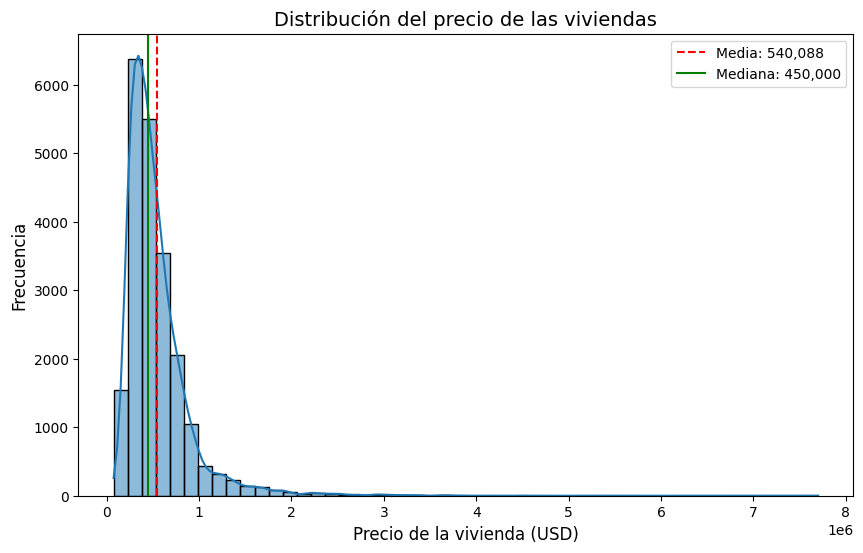

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))

sns.histplot(df["price"], bins=50, kde=True)

plt.title("Distribución del precio de las viviendas", fontsize=14)
plt.xlabel("Precio de la vivienda (USD)", fontsize=12)
plt.ylabel("Frecuencia", fontsize=12)

# Líneas de referencia
mean_price = df["price"].mean()
median_price = df["price"].median()

plt.axvline(mean_price, color="red", linestyle="--", label=f"Media: {mean_price:,.0f}")
plt.axvline(median_price, color="green", linestyle="-", label=f"Mediana: {median_price:,.0f}")

plt.legend()
plt.show()

La distribución del precio presenta asimetría positiva, evidenciada por una media superior a la mediana.

Esto indica la existencia de propiedades con precios elevados que generan una cola hacia la derecha en la distribución.

La mayoría de las viviendas se concentran en rangos intermedios de precio.

#### Distribución del área habitable (sqft_living)

Se analiza la distribución del área habitable para identificar patrones de concentración y valores extremos.

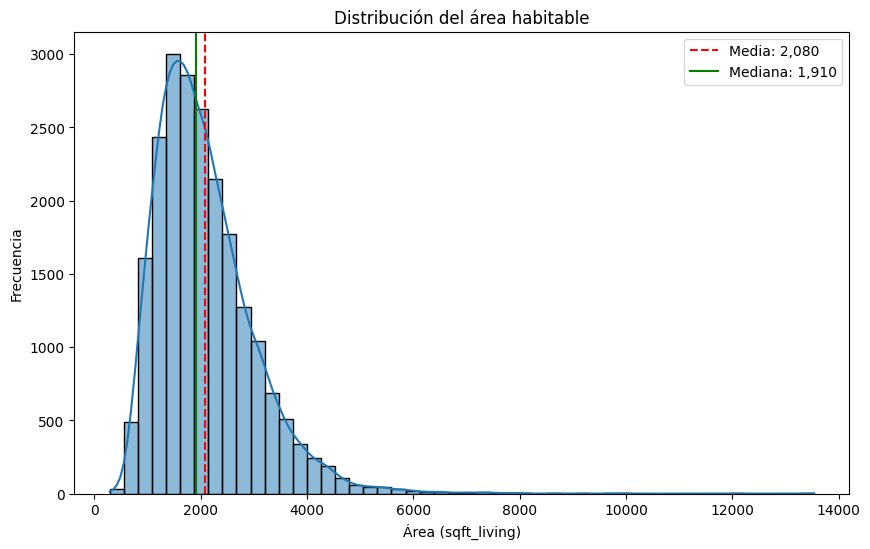

In [15]:
plt.figure(figsize=(10,6))

sns.histplot(df["sqft_living"], bins=50, kde=True)

plt.title("Distribución del área habitable")
plt.xlabel("Área (sqft_living)")
plt.ylabel("Frecuencia")

mean_area = df["sqft_living"].mean()
median_area = df["sqft_living"].median()

plt.axvline(mean_area, color="red", linestyle="--", label=f"Media: {mean_area:,.0f}")
plt.axvline(median_area, color="green", linestyle="-", label=f"Mediana: {median_area:,.0f}")

plt.legend()
plt.show()

La variable sqft_living presenta también asimetría positiva, con valores extremos hacia áreas grandes.

La mayoría de las viviendas tienen tamaños moderados, mientras que unas pocas propiedades presentan dimensiones considerablemente superiores.

#### Distribución de la calidad de construcción (grade)

Se analiza la variable grade, la cual representa la calidad de construcción de la vivienda en una escala discreta.

Dado su carácter ordinal, esta variable permite evaluar cómo se distribuyen los niveles de calidad en el dataset.

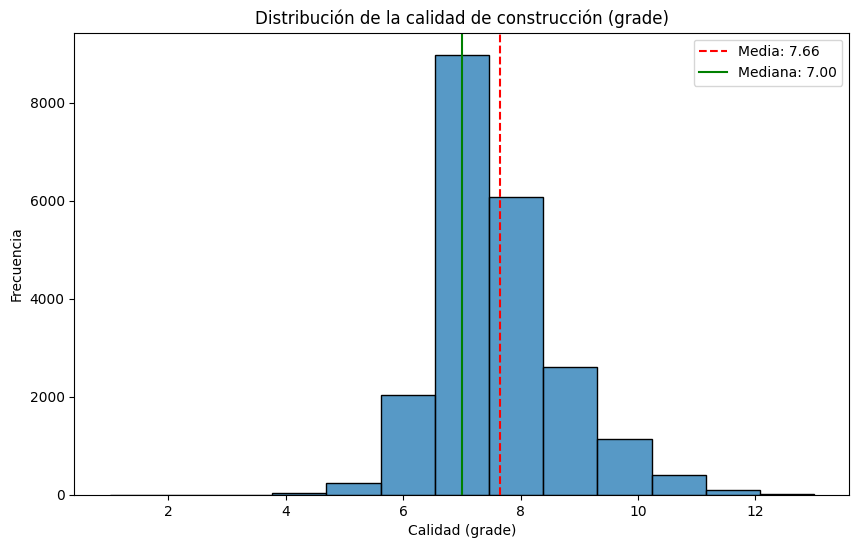

In [16]:
plt.figure(figsize=(10,6))

sns.histplot(df["grade"], bins=13, kde=False)

plt.title("Distribución de la calidad de construcción (grade)")
plt.xlabel("Calidad (grade)")
plt.ylabel("Frecuencia")

mean_grade = df["grade"].mean()
median_grade = df["grade"].median()

plt.axvline(mean_grade, color="red", linestyle="--", label=f"Media: {mean_grade:.2f}")
plt.axvline(median_grade, color="green", linestyle="-", label=f"Mediana: {median_grade:.2f}")

plt.legend()
plt.show()

La variable grade presenta una distribución concentrada en valores intermedios, principalmente entre 6 y 8.

La media (≈ 7.65) y la mediana (≈ 7) son cercanas, lo que sugiere una distribución relativamente simétrica en comparación con variables como price.

Esto indica que la mayoría de las viviendas tienen una calidad de construcción media, mientras que los valores extremos (muy baja o muy alta calidad) son menos frecuentes.

Dado su comportamiento y su naturaleza ordinal, esta variable es altamente relevante para explicar el precio de las viviendas.

#### Distribución del número de baños (bathrooms)

Se analiza la variable bathrooms, que representa el número de baños en la vivienda.

A diferencia de bedrooms, esta variable presenta mayor variabilidad y granularidad, lo que la hace más informativa para el análisis.

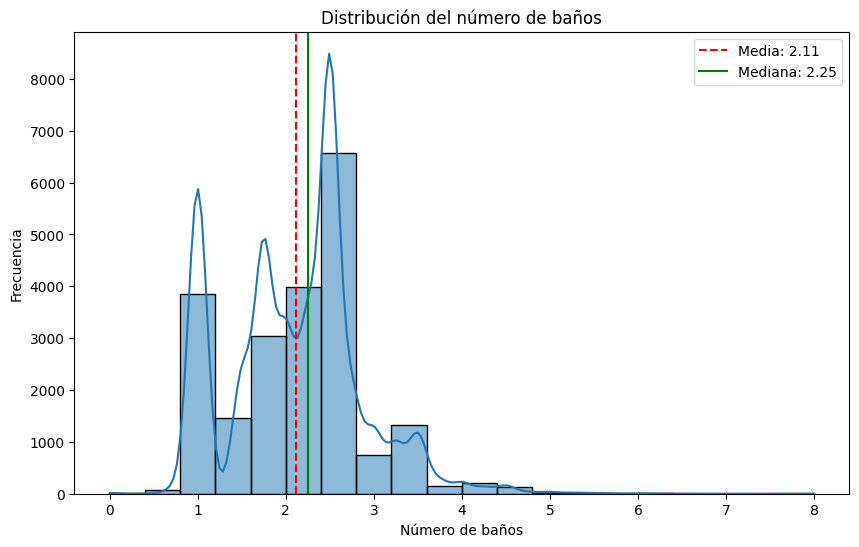

In [17]:
plt.figure(figsize=(10,6))

sns.histplot(df["bathrooms"], bins=20, kde=True)

plt.title("Distribución del número de baños")
plt.xlabel("Número de baños")
plt.ylabel("Frecuencia")

mean_bath = df["bathrooms"].mean()
median_bath = df["bathrooms"].median()

plt.axvline(mean_bath, color="red", linestyle="--", label=f"Media: {mean_bath:.2f}")
plt.axvline(median_bath, color="green", linestyle="-", label=f"Mediana: {median_bath:.2f}")

plt.legend()
plt.show()

La variable bathrooms presenta una ligera asimetría positiva, con una media (≈ 2.11) cercana a la mediana (≈ 2.25).

La mayor concentración de viviendas se encuentra entre 1.5 y 2.5 baños, lo que corresponde a configuraciones típicas en viviendas residenciales.

Se observan algunos valores más altos, aunque menos frecuentes, lo que indica la presencia de propiedades más grandes o de mayor lujo.

Esta variable es relevante para el análisis, ya que refleja el nivel de comodidad de la vivienda y tiene impacto en el precio.

### 2.3 Identificación de valores atípicos

En esta subsección se analizan los valores atípicos de las variables numéricas más relevantes del problema de regresión.

Los valores atípicos son observaciones que se encuentran significativamente alejadas del comportamiento general de los datos. En contextos inmobiliarios, estos valores pueden corresponder a propiedades excepcionalmente grandes, costosas o con características poco comunes.

Para su identificación se utilizarán diagramas de caja (*boxplots*) y, de manera complementaria, el criterio del rango intercuartílico (IQR), el cual permite establecer límites inferiores y superiores a partir de los cuartiles de cada variable.

In [18]:
variables_outliers = ["price", "sqft_living", "bathrooms", "bedrooms"]
variables_outliers

['price', 'sqft_living', 'bathrooms', 'bedrooms']

Se seleccionan las variables `price`, `sqft_living`, `bathrooms` y `bedrooms` por las siguientes razones:

- `price`: es la variable objetivo y su comportamiento extremo puede afectar directamente los modelos de regresión.
- `sqft_living`: representa el área habitable, una de las variables más influyentes en el precio.
- `bathrooms`: refleja nivel de comodidad y tamaño funcional de la vivienda.
- `bedrooms`: permite detectar configuraciones inusuales, como viviendas con un número excesivo de habitaciones.

Estas variables permiten evaluar si existen observaciones excepcionales y si dichas observaciones son plausibles dentro del contexto del mercado inmobiliario.